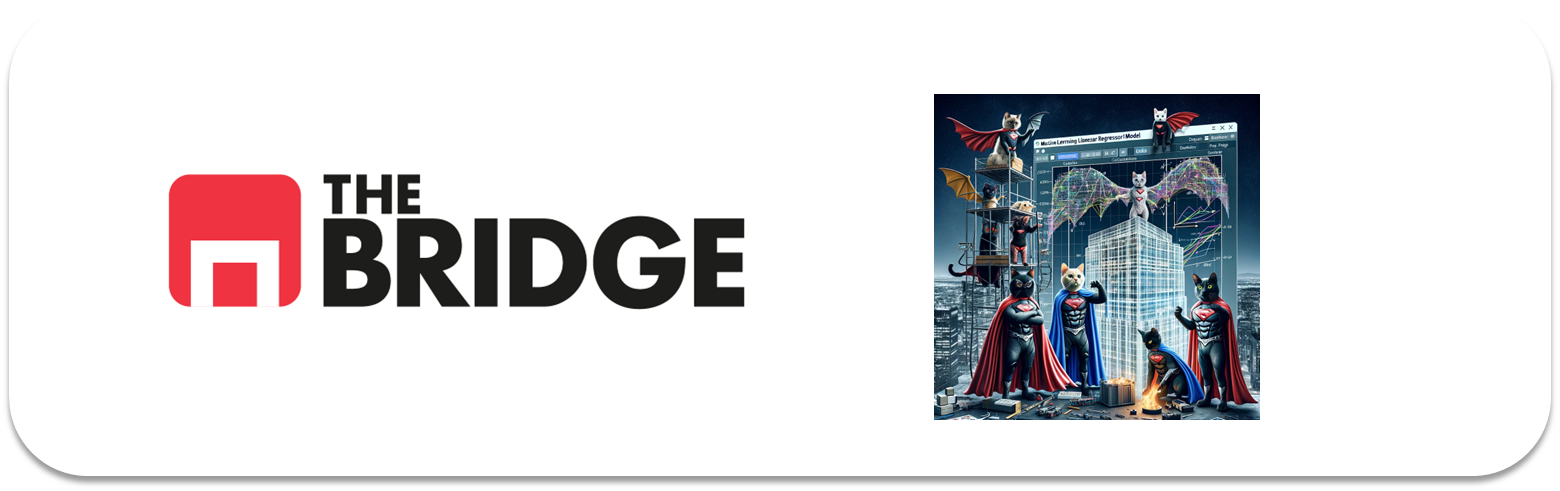

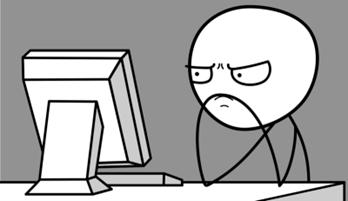

Para ejercitarte y afianzar lo aprendido sobre **Regresión Logistica aplicada a Multiclase**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

En este conjunto de ejercicios crearás un modelo para resolver un problema multiclase o multicategórico de clasificación, en concreto de clasificación de flores en función de una serie de características de las mismas (otro de esos famosos datasets de aprendizajes, el "iris" dataset)

### Ejercicio 1: Carga de Datos

Cargar el conjunto de datos Iris, que se encuentra dentro del módulo de datasets de `sklearn` (load_iris en sklearn.datasets). Repasa el ejercicio sobre "Diabetes" de la unidad anterior para saber como construir un dataframe de características y una variable con el target.

In [2]:
iris = datasets.load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target

### Ejercicio 2



Muestra la info básica del dataset y sus primeras líneas. ¿Hay variables categóricas? Muestra el target y su distribución.

In [3]:
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
iris_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


<Axes: xlabel='target', ylabel='count'>

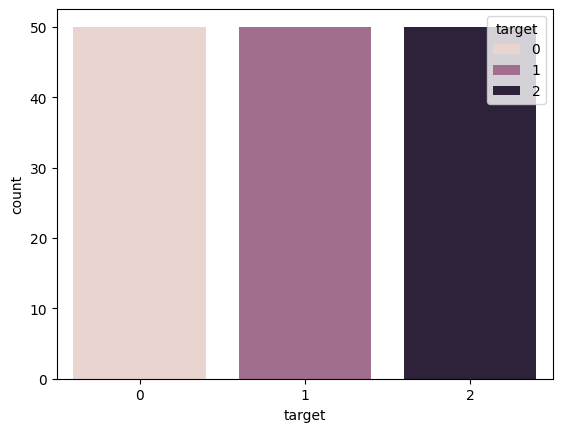

In [5]:
sns.countplot(x='target', data = iris_df, hue = 'target')

### Ejercicio 3: Preparación de Datos

Divide el conjunto de datos en un 80% para entrenamiento y un 20% para pruebas (test). Crea el X_train, X_test, y_train e y_test. Normaliza las características para que tengan una media de 0 y una desviación estándar de 1. ?Qué tipo de escalado habrás hecho?


In [6]:
train_set, test_set = train_test_split(iris_df, test_size=0.2, random_state=43)

X_train = train_set.drop('target', axis=1)
X_test = test_set.drop('target', axis=1)
y_train = train_set['target']
y_test = test_set['target']

In [7]:
scaler= StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns= X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns = X_test.columns)

In [8]:
X_train_scaled.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,1.200000e+02,1.200000e+02,1.200000e+02,1.200000e+02
mean,-4.921989e-16,-2.220446e-17,1.591320e-16,-5.551115e-17
std,1.004193e+00,1.004193e+00,1.004193e+00,1.004193e+00
min,-1.964555e+00,-2.428968e+00,-1.661246e+00,-1.536960e+00
25%,-8.478606e-01,-6.000980e-01,-1.310175e+00,-1.133088e+00
50%,-1.033976e-01,-1.428805e-01,3.574092e-01,2.131551e-01
75%,7.651425e-01,6.000980e-01,7.377354e-01,7.516522e-01
max,2.502223e+00,2.600425e+00,1.673923e+00,1.694022e+00


In [9]:
X_test_scaled.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,30.000000,30.000000,30.000000,30.000000
mean,-0.248154,-0.059057,-0.237460,-0.284955
std,1.111254,0.980040,1.138877,1.097771
min,-1.840478,-1.514533,-1.485710,-1.536960
25%,-1.220092,-0.600098,-1.412571,-1.402336
50%,-0.289513,-0.142880,0.006339,-0.325342
75%,0.268834,0.485794,0.562200,0.650684
max,2.254068,3.057642,1.790947,1.694022


### Ejercicio 4: Entrenamiento del Modelo de Regresión Logística

Ahora que los datos están listos, es el momento de construir y entrenar tu modelo de regresión logística. Inicializa y entrenar un modelo de regresión logística utilizando el conjunto de entrenamiento (con tan pocos datos no es necesario que ajustes el hiperparámetro "max_iter")


In [10]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Ejercicio 5: Evaluación del train

Obtén las predicciones para el dataset de train y luego calcula y muestra la matriz de confusión y genera y muestra un informe de clasificación.

In [11]:
pred_train = model.predict(X_train_scaled)

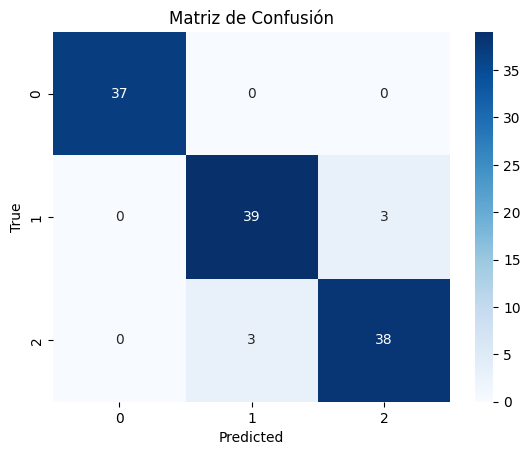

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       0.93      0.93      0.93        42
           2       0.93      0.93      0.93        41

    accuracy                           0.95       120
   macro avg       0.95      0.95      0.95       120
weighted avg       0.95      0.95      0.95       120



In [12]:
conf_matrix = confusion_matrix(y_train, pred_train)

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

report = classification_report(y_train, pred_train)
print(report)

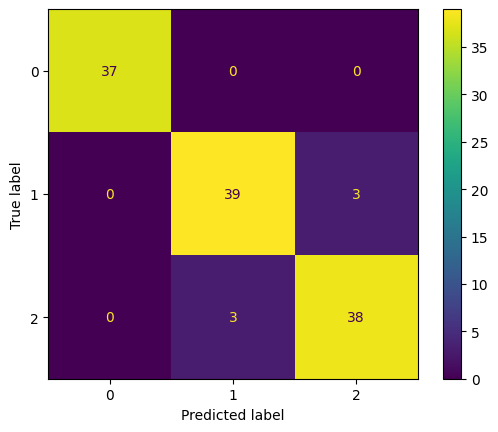

In [13]:
ConfusionMatrixDisplay.from_predictions(y_train, pred_train)

### Ejercicio 6: Evaluación del test

Obtén las predicciones para el dataset de test y luego calcula y muestra la matriz de confusión y genera y muestra un informe de clasificación.

In [14]:
pred_test= model.predict(X_test_scaled)

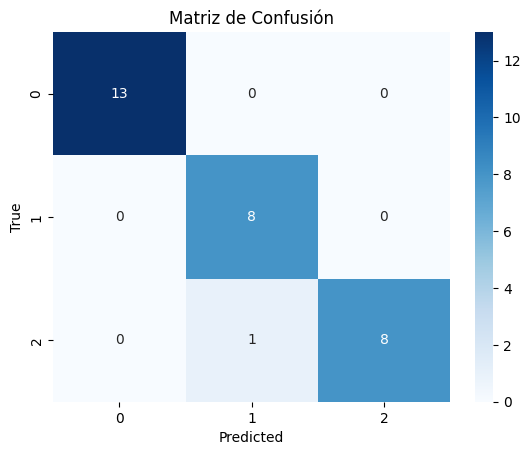

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.89      1.00      0.94         8
           2       1.00      0.89      0.94         9

    accuracy                           0.97        30
   macro avg       0.96      0.96      0.96        30
weighted avg       0.97      0.97      0.97        30



In [15]:
conf_matrix = confusion_matrix(y_test, pred_test)

sns.heatmap(conf_matrix, annot= True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

report = classification_report(y_test, pred_test)
print(report)

### Ejercicio 7: Interpretación de los coeficientes del modelo

Muestra los coeficientes para cada clasificador numéricamente


In [16]:
model.coef_

array([[-1.00485905,  1.06678684, -1.80588859, -1.69353613],
       [ 0.4937744 , -0.33607561, -0.27714597, -0.80817448],
       [ 0.51108465, -0.73071122,  2.08303456,  2.50171061]])

### Ejercicio 8: Interpretación de los coeficientes del modelo (II)

Modifica la siguiente función y pinta los coeficientes obtenidos en el ejercicio anterior:

```python
def show_coefs(model, figsize=(10, 5)):
    df_coef = pd.DataFrame(model.coef_[0], index=model.feature_names_in_, columns=["coefs"])

    fig, ax = plt.subplots(1, 2, figsize=figsize)
    df_coef.plot(kind="barh", ax=ax[0], legend=False)
    df_coef.abs().sort_values(by="coefs").plot(kind="barh", ax=ax[1], legend=False)
    fig.suptitle("Model Coefficients")

    fig.tight_layout()

    return df_coef
```

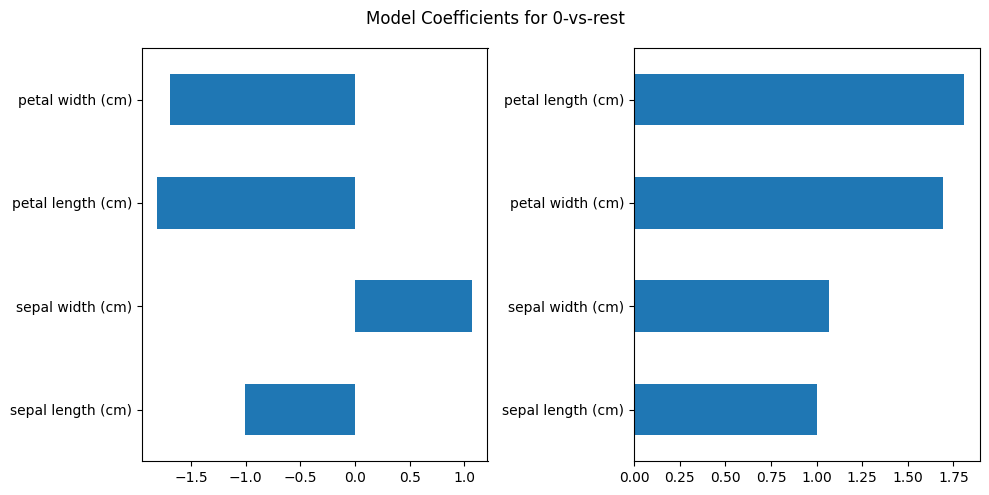

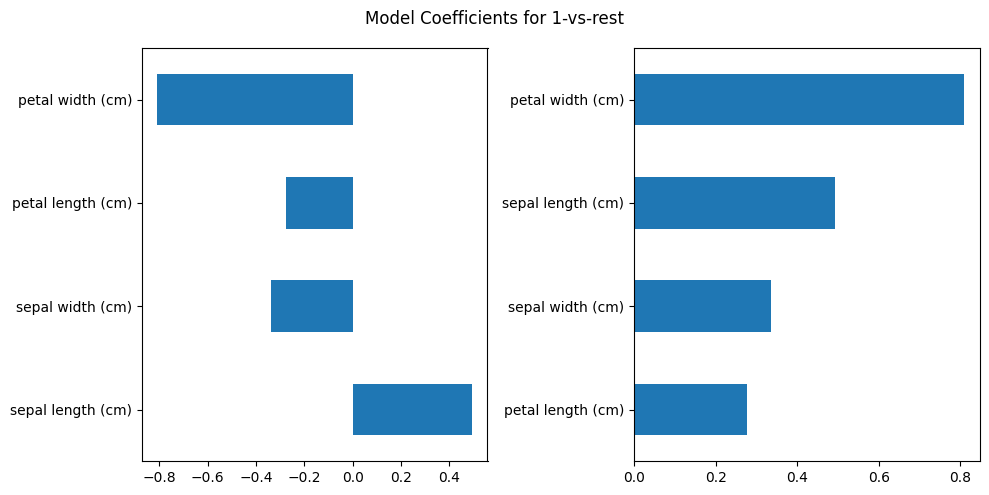

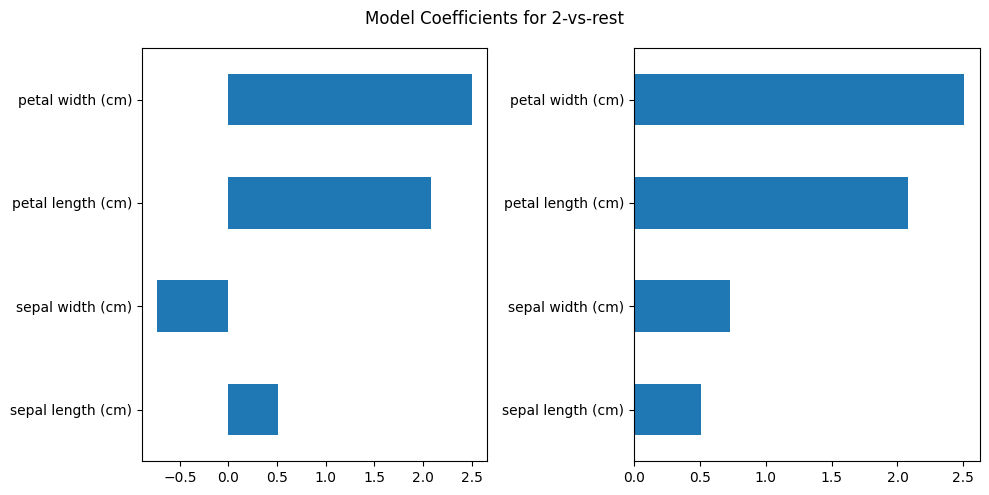

In [17]:
# Por fuera
# Las gráficas de la derecha son los mismos coeficientes en valor absoluto

def show_coefs(model, figsize=(10, 5), model_index = 0): # Metemos el índice para indicar que modelo pintar
    df_coef = pd.DataFrame(model.coef_[model_index], index=model.feature_names_in_, columns=["coefs"]) # El indice dice que juego de coeficientes considerar

    fig, ax = plt.subplots(1, 2, figsize=figsize)
    df_coef.plot(kind="barh", ax=ax[0], legend=False)
    df_coef.abs().sort_values(by="coefs").plot(kind="barh", ax=ax[1], legend=False)
    fig.suptitle(f"Model Coefficients for {model_index}-vs-rest") # Cambiamos la leyenda para ver qué modelo está presentando

    fig.tight_layout()

    return df_coef

for model_index in range(3): # Para cada modelo aplicamos la función
    show_coefs(model, model_index = model_index)

[                      coefs
 sepal length (cm) -1.004859
 sepal width (cm)   1.066787
 petal length (cm) -1.805889
 petal width (cm)  -1.693536,
                       coefs
 sepal length (cm)  0.493774
 sepal width (cm)  -0.336076
 petal length (cm) -0.277146
 petal width (cm)  -0.808174,
                       coefs
 sepal length (cm)  0.511085
 sepal width (cm)  -0.730711
 petal length (cm)  2.083035
 petal width (cm)   2.501711]

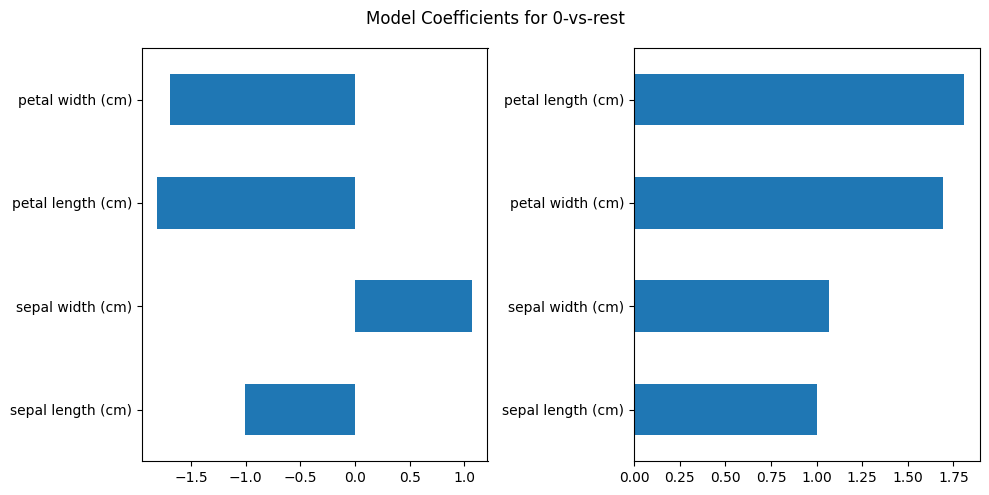

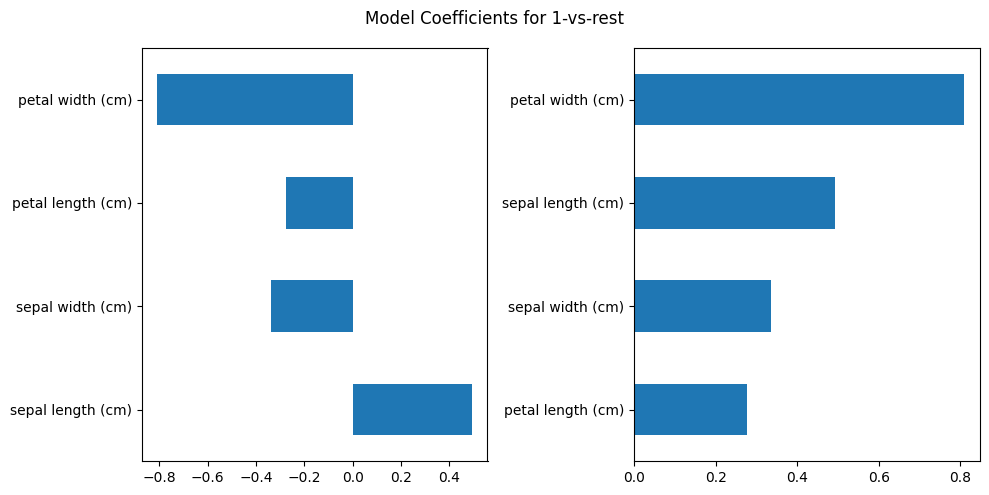

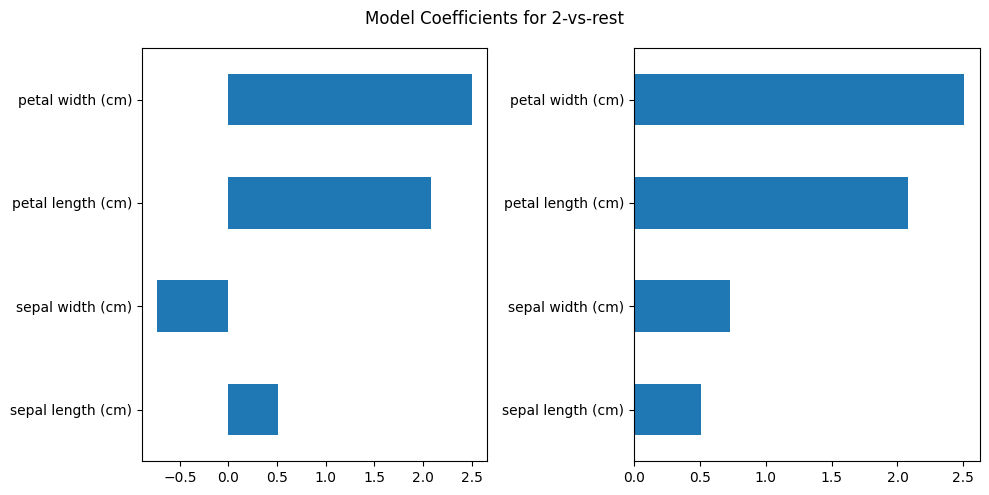

In [18]:
def show_coefs(model, figsize=(10, 5)): 
    number_of_submodels = model.coef_.shape[0] # Obtenemos el número de submodelos, ya que coef_ devuelve un array de dimensión 2 (ndim de numpy ojo) y la cardinalidad de la primera da el numero de modelos o sea el número de clases
    # number_of_submodels = len(model.classes_), sería una opción alternativa.
    list_of_dfs = []
    for model_index in range(number_of_submodels):
        df_coef = pd.DataFrame(model.coef_[model_index], index=model.feature_names_in_, columns=["coefs"]) # El indice dice que juego de coeficientes considerar

        fig, ax = plt.subplots(1, 2, figsize=figsize)
        df_coef.plot(kind="barh", ax=ax[0], legend=False)
        df_coef.abs().sort_values(by="coefs").plot(kind="barh", ax=ax[1], legend=False)
        fig.suptitle(f"Model Coefficients for {model_index}-vs-rest") # Cambiamos la leyenda para ver qué modelo está presentando

        fig.tight_layout()
        list_of_dfs.append(df_coef.copy())

    return list_of_dfs

show_coefs(model)